In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading ML Table


In [3]:
PROJECT_DIR = Path.cwd()
ARTIFACTS = PROJECT_DIR / "artifacts"

ml_table = pd.read_csv(ARTIFACTS / "01_ml_table.csv")

for col in [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]:
    ml_table[col] = pd.to_datetime(ml_table[col], errors="coerce")

## Creating Lag Label


In [2]:
labeled = ml_table.dropna(
    subset=[
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
).copy()

labeled["is_late"] = (
    labeled["order_delivered_customer_date"] >
    labeled["order_estimated_delivery_date"]
).astype(int)

labeled["delivery_status"] = labeled["is_late"].map({
    0: "On Time",
    1: "Late"
})

##  Checking Label and Class Distribution


In [4]:
display(labeled[[
    "order_id",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "is_late",
    "delivery_status"
]].head(10))

summary = labeled["delivery_status"].value_counts().to_frame("count")
summary["percentage"] = summary["count"] / len(labeled) * 100
display(summary)

,order_id,order_delivered_customer_date,order_estimated_delivery_date,is_late,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,0,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,0,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,0,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,0,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,0,On Time
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-26 10:57:55,2017-08-01,0,On Time
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-26 12:55:51,2017-06-07,0,On Time
8,76c6e866289321a7c93b82b54852dc33,2017-02-02 14:08:10,2017-03-06,0,On Time
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-08-16 17:14:30,2017-08-23,0,On Time
10,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-29 11:18:31,2017-06-07,0,On Time


,count,percentage
delivery_status,,
On Time,88649,91.887101
Late,7827,8.112899


## Plotting and Saving Class Distribution


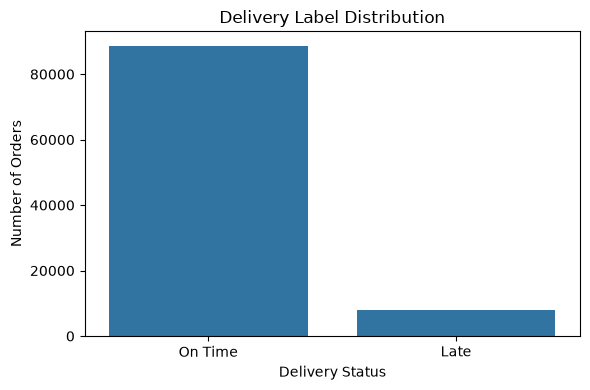

In [5]:
FIGURES = PROJECT_DIR / "figures"
FIGURES.mkdir(exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(data=labeled, x="delivery_status")
plt.title("Delivery Label Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(FIGURES / "label_distribution.png", dpi=150)
plt.show()

## Saving Artifacts


In [6]:
output_file = ARTIFACTS / "02_labeled.csv"
labeled.to_csv(output_file, index=False, encoding="utf-8-sig")
print("Saved:", output_file)

Saved: C:\Users\HP\Desktop\MLOPS\Tasks\task2\MLOps_Task2\notebooks\artifacts\02_labeled.csv
